# **Mentoring 2** - Credit Scoring and Analytics
Sekolah Data - Pacmann

In [7]:
# Load data manipulation package
import numpy as np
import pandas as pd

# Load data visualization package
import matplotlib.pyplot as plt
import seaborn as sns
from fontTools.mtiLib import makeAnchor
from matplotlib.sphinxext.plot_directive import PlotError, plot_context

In [8]:
PATH_DATA = 'credit_risk_dataset.csv'

---
**Mentoring 2 to assess your understanding of these topics**:
1. Descriptive Statistics
2. Contingency Table and Probability Structure
3. Test of Independence
4. Odds and Odds Ratio
5. Likelihood Function and MLE
6. Optimization of Log Loss
7. Logistic Model Interpretation

# **Case 1**: Loan Applicant Analysis

This dataset contains information on loan applicants, including demographic details, financial status, loan characteristics, and credit history. It helps analyze factors affecting loan approval and default risk.

🔗 [Download dataset here](https://drive.google.com/file/d/1hw1WIjoe0HVABe5bMfa27yrOqv-JhD3q/view?usp=sharing)

---

### **Data Preparation**:

In [59]:
# Import dataset from csv file
data = pd.read_csv(PATH_DATA)

# Table check
data

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [10]:
# Information check
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [13]:
data["person_emp_length"].value_counts()

person_emp_length
0.0      4105
2.0      3849
3.0      3456
5.0      2946
1.0      2915
4.0      2874
6.0      2666
7.0      2196
8.0      1687
9.0      1367
11.0      740
10.0      696
12.0      575
13.0      426
14.0      335
15.0      238
16.0      165
17.0      129
18.0      104
19.0       64
20.0       42
21.0       38
22.0       19
24.0       10
23.0       10
25.0        8
26.0        6
27.0        5
31.0        4
28.0        3
123.0       2
30.0        2
41.0        1
34.0        1
29.0        1
38.0        1
Name: count, dtype: int64

## Split Train-Test Data

In [30]:
response_variable = "loan_status"

y = data[response_variable]
X = data.drop(columns=[response_variable], axis=1)

print('y shape : ', y.shape)
print('X shape : ', X.shape)

y shape :  (32581,)
X shape :  (32581, 11)


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Validate splitting
print('X train shape :', X_train.shape)
print('y train shape :', y_train.shape)
print('X test shape  :', X_test.shape)
print('y test shape  :', y_test.shape)

print(y_train.value_counts(normalize = True))
print(y_test.value_counts(normalize = True))

X train shape : (26064, 11)
y train shape : (26064,)
X test shape  : (6517, 11)
y test shape  : (6517,)
loan_status
0    0.782727
1    0.217273
Name: proportion, dtype: float64
loan_status
0    0.778272
1    0.221728
Name: proportion, dtype: float64


In [36]:
data_train = pd.concat((X_train, y_train), axis=1)

#### **Question 1**:
Describe the type of data and measurement scale of each variable.

e.g. :
```
| Column                | Type of Data | Measurement Scale |
|-----------------------|--------------|-------------------|
| ID                    | Numerical    | Nominal           |
| AGE                   | Numerical    | Continuos         |
...
```

---

| Column                     | Type of Data | Measurement Scale |
|----------------------------|--------------|-------------------|
| person_age                 | Numerical    | Discrete          |
| person_income              | Numerical    | Discrete          |
| person_home_ownership      | Categorical  | Nominal           |
| person_emp_length          | Numerical    | Discrete          |
| loan_intent                | Categorical  | Nominal           |
| loan_grade                 | Categorical  | Ordinal           |
| loan_amnt                  | Numerical    | Discrete          |
| loan_int_rate              | Numerical    | Continuous        |
| loan_status                | Numerical    | Discrete          |
| loan_percent_income        | Numerical    | Continuous        |
| cb_person_default_on_file  | Categorical  | Nominal           |
| cb_person_cred_hist_length | Numerical    | Discrete          |

### **Question 2**:
Make a descriptive statistics and visualization of each variable.

---

**1. person_home_ownership**
- What types of home ownership historically get loan credit more?

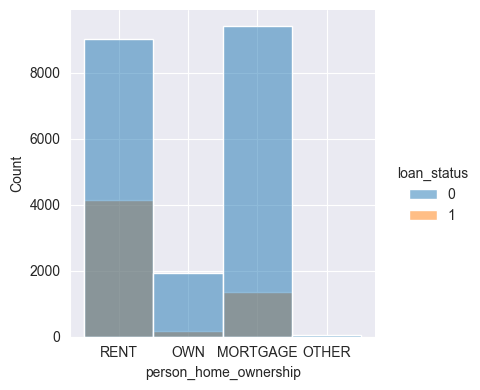

In [37]:
# Answer Here
import seaborn as sns

sns.displot(data=data_train, x="person_home_ownership", hue="loan_status", height=4)

Berdasarkan distribution plot di atas, maka tipe home ownership "Mortgage" memiliki jumlah peminjaman terbanya

### Answer Here
Berdasarkan distribution plot di atas, maka tipe home ownership "Rent" memiliki jumlah peminjaman terbanya

**2. Age**
- What is the average and median age of the customer?

In [39]:
data_train["person_age"].describe()

count    26064.000000
mean        27.764695
std          6.392500
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max        144.000000
Name: person_age, dtype: float64

Berdasarkan tabel di atas, dapat disimpulkan :
1. Rata-rata usia customer : 27.73
2. Nilai tengah (median) customer : 26.0

- Visualize the variation in the buyer's age compared loan_status.
- What can you conclude?

<Axes: xlabel='loan_status', ylabel='person_age'>

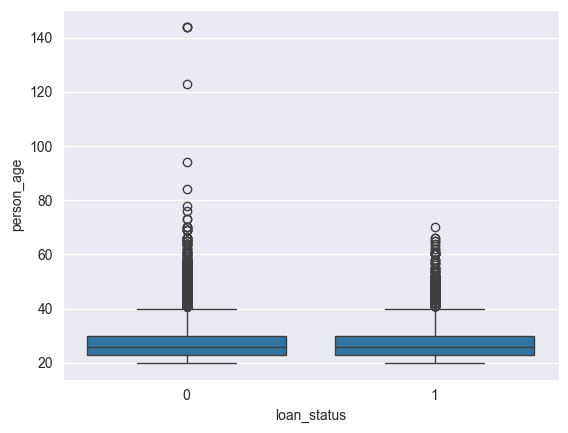

In [41]:
sns.boxplot(data=data_train, x='loan_status', y='person_age')

In [42]:
data_train['person_age'].groupby(data_train['loan_status']).describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,20401.0,27.839273,6.425516,20.0,23.0,26.0,30.0,144.0
1,5663.0,27.496027,6.265323,20.0,23.0,26.0,30.0,70.0


Terdapat kemungkinan outlier untuk umur 80 keatas.
Tidak ada perbedaan signifikan antara kedua status

**3. person_income**
- What is the average and distribution of person_income?

In [29]:
# Answer Here
data['person_income'].describe()

count    3.258100e+04
mean     6.607485e+04
std      6.198312e+04
min      4.000000e+03
25%      3.850000e+04
50%      5.500000e+04
75%      7.920000e+04
max      6.000000e+06
Name: person_income, dtype: float64

- Visualize the variation in the person_income compared between default and non default
- What can you conclude?

<Axes: xlabel='loan_status', ylabel='person_income'>

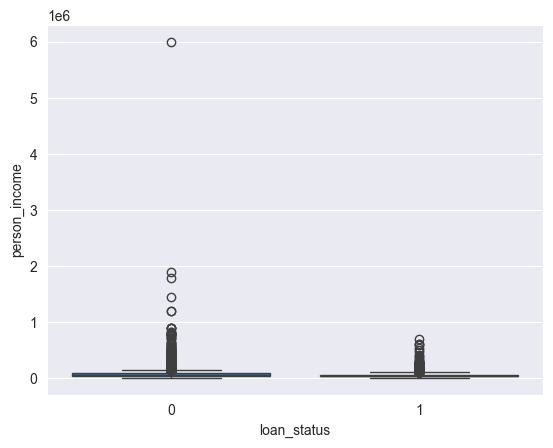

In [44]:
sns.boxplot(data=data_train, x='loan_status', y='person_income')

In [48]:
data_train["person_income"].groupby(data_train[response_variable]).describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,20401.0,70898.292143,68441.735152,7000.0,42000.0,60000.0,84600.0,6000000.0
1,5663.0,49144.778386,37032.454784,4000.0,30000.0,42000.0,59667.5,703800.0


### **Question 3**:
What is the probability of a customer default, given they are under 30 years old?

In [97]:
# Answer Here
customers_default_by_age = data_train[(data_train["person_age"] < 30) & (data_train[response_variable] == 1)]

print("Probabilities of default customer under 30 : ", len(customers_default_by_age) / len(data_train))

Probabilities of default customer under 30 :  0.16025936157151627


What is the probability of a customer default, given the loan_percent_income > half of the income ? Interpret the result

In [96]:
customers_default_by_income = data_train[(data_train["loan_percent_income"] > 0.5) & (data_train[response_variable] == 1)]

print("Probabilities of default customer : ", len(customers_default_by_income) / len(data_train))

Probabilities of default customer :  0.005793431553100061


What is the probability of a customer default, given the loan_int_rate > 10% ? Interpret the result

In [95]:
customers_by_interest_rate = data_train[(data_train["loan_int_rate"] > 10.0) & (data_train[response_variable] == 1)]

print("Probabilities of default customer : ", len(customers_by_interest_rate) / len(data_train))

Probabilities of default customer :  0.15826427255985268


### **Question 4**:
From a sample of customers, construct a two way contingency table based on their cb_person_default_on_file and loan_status.

In [68]:
# Answer Here
contingency_table = pd.crosstab(data_train["cb_person_default_on_file"], data_train["loan_status"])
contingency_table

loan_status,0,1
cb_person_default_on_file,,
N,17563,3951
Y,2838,1712


What is the probability of each cb_person_default_on_file default?

In [ ]:
# Answer Here

### **Question 5**:
What is the probability of each person_home_ownership (Rent and Mortgage) default?

**Default n Mortgage**

In [100]:
customer_mortgage = data_train[(data_train["person_home_ownership"] == "MORTGAGE") & (data_train[response_variable] == 1)]
customer_mortgage_probabilities = len(customer_mortgage) / len(data_train)

print("Probabilities of customer mortgage : ", customer_mortgage_probabilities)

Probabilities of customer mortgage :  0.05125844076120319


**Default n Rent**

In [101]:
customer_rent = data_train[(data_train["person_home_ownership"] == "RENT") & (data_train[response_variable] == 1)]
customer_rent_probabilities = len(customer_rent) / len(data_train)

print("Probabilities of customer rent : ", customer_rent_probabilities)

Probabilities of customer rent :  0.1589548802946593


### **Question 6**:
Conduct a $\chi^{2}$ test of independence between default (loan status)
and loan_intent. Use $\alpha=0.05$.

State the hypotheses:
- $\text H_{0}:$ The default probability is independent of customer's loan_intent.
- $\text H_{1}:$ The default probability is not independent of customer's loan_intent.

### **Question 7**:
What is the odds ratio of default between `DEBTCONSOLIDATION` and `HOMEIMPROVEMENT`?

In [107]:
# Answer Here
data_train_intent = data_train[
    ((data_train["loan_intent"] == "DEBTCONSOLIDATION") | (data_train["loan_intent"] == "HOMEIMPROVEMENT"))
]

# Answer Here
contingency_table = pd.crosstab(data_train_intent["loan_intent"], data_train[response_variable])
contingency_table

loan_status,0,1
loan_intent,,
DEBTCONSOLIDATION,3013,1203
HOMEIMPROVEMENT,2155,730


### **Question 8**:
what can you conclude about the relationship between default with these variables:

- `person_home_ownership`
- `loan_intent`
- `cb_person_default_on_file`

What evidence do you have? Are they good predictors for loan_status? Explain.

In [ ]:
# Answer Here

# **Case 2**: Logistic Regression

## **Data Preparation**:

In [ ]:
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
# Filter dataset
# We will only use 2 variables: loan_percent_income and loan_status

df = data[['loan_percent_income','loan_status']].copy()
df.head()

,loan_percent_income,loan_status
0,0.59,1
1,0.10,0
2,0.57,1
3,0.53,1
4,0.55,1


In [ ]:
# Information check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   loan_percent_income  32581 non-null  float64
 1   loan_status          32581 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 509.2 KB


- Check for missing value before analysis.
- Then perform a simple imputation.

In [ ]:
# Checking missing value
df.isnull().sum()

loan_percent_income    0
loan_status            0
dtype: int64

- There are no missing values on `loan_percent_income    ` (a numerical variable)

## **Question 1**:
Construct the likelihood function for those 32581 credit customers. Make it in latex markdown

In [ ]:
# Answer Here

[Answer Here]

## **Question 2**:
Make a plot of likelihood/log-likelihood value for each estimate of $\pi(x)$, where $\pi(x)$ in range [0.1, 0.9]. At which $\pi(x)$ the likelihood function takes its maximum value? Explain.

In [ ]:
# Answer Here

## **Question 3**:
Use logistic regression to model the effect of loan_percent_incomeon the probability
of default.

In [ ]:
# Answer Here

## **Question 4**:
Describe the estimated effect loan_percent_income on the odds of default.

In [ ]:
# Answer Here

## **Question 5**:
At what loan percent income does the estimated probability of default equal 0.50? At that loan percent income, give a linear approximation

In [ ]:
# Answer Here

## **Question 6**:
Test the hypothesis that loan_percent_income has no effect to probability of default.

In [ ]:
# Answer Here

## **Question 7**:
Use logistic regression to model the effect of **standardized loan_percent_income** on the probability
of default

In [ ]:
# Answer Here

## **Question 8**:
Based on the parameter estimate of standardized loan percent income, describe the estimated effect of **loan percent income** on the odds of default.

In [ ]:
# Answer Here

## **Question 9**:
Based on the parameter estimate of standardized annual mileage, describe the estimated effect of **annual loan percent income** on the odds of default.

In [ ]:
# Answer Here